# MetaLore Simulator — Getting Started

**MetaLore** is a Gymnasium-compatible reinforcement learning environment for smart city wireless sensor network simulation.

### What does it simulate?

| Entity | Role |
|---|---|
| **Base Station (BS)** | Wireless access point with bandwidth and edge server with compute capacity |
| **User Equipment (UE)** | Mobile device that generates service requests |
| **Sensor** | IoT device that continuously streams context data |

### What does the agent control?

At each timestep the agent outputs **two continuous actions** in [0, 1]:

- `bw_split` — fraction of total bandwidth allocated to UEs (the rest goes to sensors)
- `comp_split` — fraction of total compute capacity allocated to UE jobs (the rest to sensor jobs)

### Job lifecycle:

```
UE generates job → TX queue in UE → wireless transmission → BS proc queue → MEC processing → done
Sensor generates job ─────────────────────────────────────────────────────------───────────→ done
```

UE jobs are only processed once a fresh sensor snapshot is available for the nearest sensor.

### Key metrics:

| Metric | Full name | Role |
|---|---|---|
| **AoRI** | Age of Request Information |  UE job end-to-end latency |
| **AoSI** | Age of Sensor Information |  sensor data staleness |

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv, MultiCellEnv
from metalore.config import default_config, small_config, large_config, mobile_sensor_config, multi_cell_config

print("MetaLore imported successfully!")

MetaLore imported successfully!


## 2. Available Configurations

MetaLore ships with five pre-built configurations. Each is a plain Python dict that you can pass directly or customise.

| Config | Scenario |
|---|---|
| `default_config` | Minimal — fast to run, good for debugging |
| `small_config` | Standard single-cell baseline |
| `large_config` | More UEs and sensors |
| `mobile_sensor_config` | Sensors that move over time |
| `multi_cell_config` | Multiple BSs |

The cell below shows their key parameters.

In [2]:
# Create environment
config = large_config()
config['environment']['seed'] = 42
config['environment']['reset_rng_episode'] = True  # reset RNG each episode for full reproducibility

# Compare environment configurations
configs = {
    'small': (SingleCellEnv, small_config()),
    'default': (SingleCellEnv, default_config()),
    'large': (SingleCellEnv, large_config()),
    'mobile_sensor': (SingleCellEnv, mobile_sensor_config()),
    'multi_cell': (MultiCellEnv, multi_cell_config()),
}

rows = []
for name, (EnvClass, config) in configs.items():
    env = EnvClass(config=config)
    env.reset()
    rows.append({
        'Config': name,
        'BSs': env.num_bs,
        'UEs': env.num_ues,
        'Sensors': env.num_sensors,
        'Width': env.width,
        'Height': env.height,
        'Max Steps': env.EP_MAX_TIME,
    })
    env.close()

config_df = pd.DataFrame(rows)
ipd.display(config_df)

,Config,BSs,UEs,Sensors,Width,Height,Max Steps
0,small,1,5,8,200.0,200.0,100
1,default,1,15,45,200.0,200.0,100
2,large,1,20,10,200.0,200.0,100
3,mobile_sensor,1,10,5,200.0,200.0,100
4,multi_cell,3,15,20,200.0,200.0,100


## 3. Running an Episode

MetaLore follows the standard [Gymnasium](https://gymnasium.farama.org/) API:

```python
obs, info                 = env.reset()                              # start a new episode
obs, r, term, trunc, info = env.step([bw_split, comp_split])         # advance one timestep
```

In [3]:
# Create environment
env = SingleCellEnv(config=default_config())
obs, info = env.reset()

print("="*60)
print("ENVIRONMENT SETUP")
print("="*60)
print(f"Base Stations: {env.num_bs}")
print(f"User Equipment: {env.num_ues}")
print(f"Sensors: {env.num_sensors}")
print(f"Area: {env.width} x {env.height}")
print(f"Max Steps: {env.EP_MAX_TIME}")
print()
print("="*60)
print("RL INTERFACE")
print("="*60)
print(f"Action Space: {env.action_space}")
print(f"Observation Space: {env.observation_space}")
print(f"Initial Observation Shape: {obs.shape}")

ENVIRONMENT SETUP
Base Stations: 1
User Equipment: 15
Sensors: 45
Area: 200.0 x 200.0
Max Steps: 100

RL INTERFACE
Action Space: Box(0.0, 1.0, (2,), float32)
Observation Space: Box(0.0, 10000.0, (2,), float32)
Initial Observation Shape: (2,)


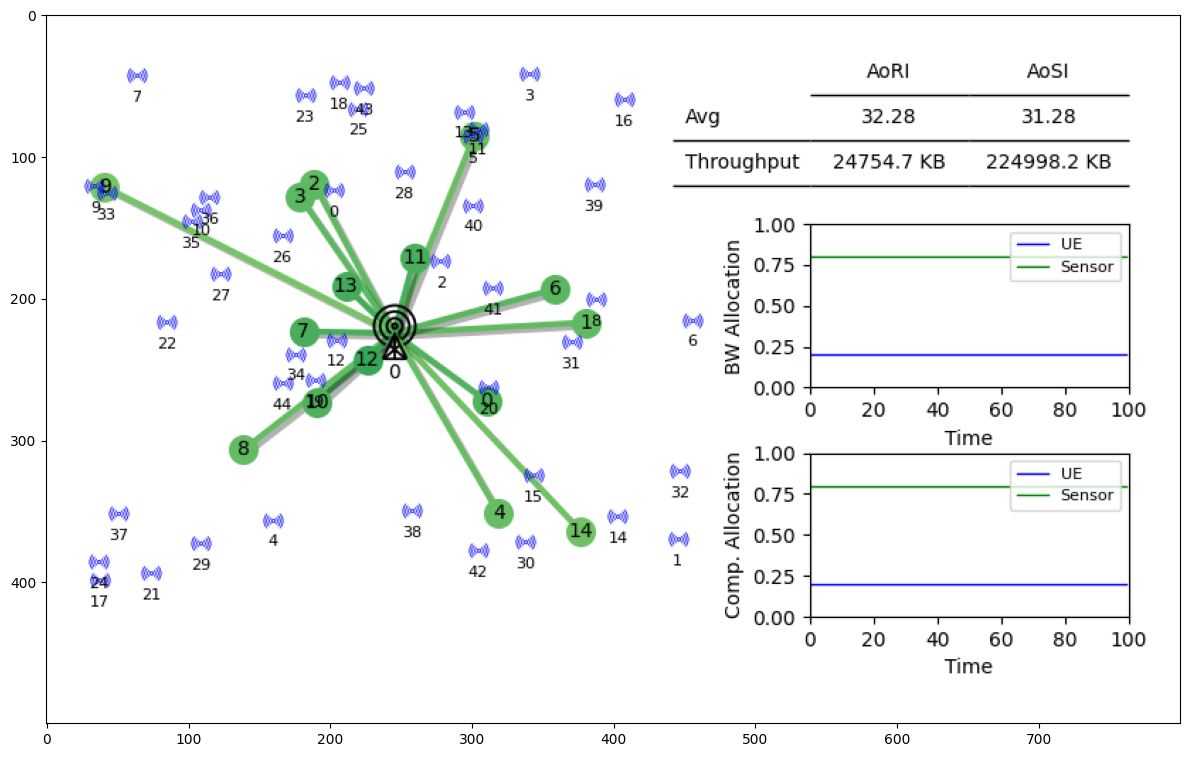

Episode ended at step 100

Steps completed : 100
Total reward    : 234.2212


In [4]:
# Run a full episode with random actions
N_STEPS =  100

rewards = []
for step in range(N_STEPS):
    #action = env.action_space.sample()   # random policy
    action = [0.2, 0.2]                   # fixed equal-split policy
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    
    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break

print()
print(f"Steps completed : {len(rewards)}")
print(f"Total reward    : {sum(rewards):.4f}")

## 4. Metrics Reference

After running an episode all data lives in `env.metrics` (a `MetricsTracker`). It is organised into **five structures** with different granularities:

| Attribute | What it holds | Keys |
|---|---|---|
| `step_totals` | One scalar per timestep, aggregated over all entities | `str → List` |
| `step_per_entity` | One value per entity per timestep | `str → {('UE'\|'SENSOR', id): List}` |
| `step_per_bs` | One value per BS per timestep — most useful for multi-cell | `str → {bs_id: List}` |
| `step_topology` | Connection-map snapshot per timestep | `str → List[dict]` |
| `ep_totals` | Episode-level scalar aggregates | `str → scalar` |
| `ep_per_entity` | Episode total per entity | `str → {('UE'\|'SENSOR', id): scalar}` |

`ep_totals` and `ep_per_entity` are populated by calling `metrics.finalize(env.job_tracker)` at the end of an episode (Section 8).

In [5]:
# Step totals — one row per timestep, aggregated over all entities
st = env.metrics.step_totals
df_totals = pd.DataFrame({k: v for k, v in st.items() if k != "observation"}).set_index("time")
print("STEP TOTALS")
ipd.display(df_totals)

STEP TOTALS


,num_active_ues,num_active_sensors,ue_tx_queue_bits,sensor_tx_queue_bits,ue_tx_queue_jobs,sensor_tx_queue_jobs,jobs_generated,jobs_transmitted,jobs_processed,bits_transmitted,...,ue_bits_transmitted,sensor_bits_transmitted,ue_cycles_processed,sensor_cycles_processed,bw_split,comp_split,reward,mean_aoi,mean_aori,mean_aosi
time,,,,,,,,,,,,,,,,,,,,,
0,15,45,0,0,0,0,55,55,45,22995754.0,...,4998277.0,17997477.0,0.0,1.125004e+09,0.2,0.2,0.000000,NaN,NaN,NaN
1,15,45,0,0,0,0,56,56,49,23496546.0,...,5501307.0,17995239.0,399985759.0,1.125010e+09,0.2,0.2,40.000000,1.0,1.00,0.00
2,15,45,0,0,0,0,56,56,49,23500831.0,...,5498930.0,18001901.0,399982938.0,1.125011e+09,0.2,0.2,36.000000,1.0,2.00,1.00
3,15,45,0,0,0,0,56,56,49,23501723.0,...,5502467.0,17999256.0,400000839.0,1.125023e+09,0.2,0.2,34.200000,1.0,2.50,1.50
4,15,45,0,0,0,0,56,56,49,23499816.0,...,5502066.0,17997750.0,399975603.0,1.124994e+09,0.2,0.2,32.400000,1.0,3.00,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,15,45,0,0,0,0,55,55,49,22997686.0,...,4999085.0,17998601.0,400046583.0,1.124985e+09,0.2,0.2,-3.920133,1.0,60.00,59.00
96,15,45,0,0,0,0,57,57,49,23990915.0,...,5998919.0,17991996.0,399998506.0,1.124976e+09,0.2,0.2,-3.922130,1.0,60.25,59.25
97,15,45,0,0,0,0,54,54,49,22511682.0,...,4501909.0,18009773.0,399988911.0,1.125044e+09,0.2,0.2,-3.926123,1.0,60.75,59.75


## 5. Per-BS Metrics (Multi-Cell)

`step_per_bs` holds one time series per base station, keyed by `bs_id`. This is most useful when running a **MultiCellEnv**, but it also works for single-cell runs (one key per dict).

| Key | Description |
|---|---|
| `ue_connections` | Number of UEs connected to this BS |
| `sensor_connections` | Number of sensors connected to this BS |
| `ue_proc_queue_jobs` | UE jobs waiting in this BS's processing queue |
| `sensor_proc_queue_jobs` | Sensor jobs waiting in this BS's processing queue |
| `ue_proc_queue_cycles` | UE compute cycles backlogged at this BS |
| `sensor_proc_queue_cycles` | Sensor compute cycles backlogged at this BS |

In [6]:
# Per-BS metrics — one time series per base station
times = env.metrics.step_totals["time"]
for metric, bs_data in env.metrics.step_per_bs.items():
    df = pd.DataFrame(
        {f"BS {bs_id}": vals for bs_id, vals in bs_data.items()},
        index=times
    )
    df.index.name = "time"
    print(f"\n{metric}")
    ipd.display(df)


ue_connections


,BS 0
time,
0,15
1,15
2,15
3,15
4,15
...,...
95,15
96,15
97,15



sensor_connections


,BS 0
time,
0,45
1,45
2,45
3,45
4,45
...,...
95,45
96,45
97,45



ue_proc_queue_jobs


...

,BS 0
time,
0,0
1,0
2,0
3,0
4,0
...,...
95,0
96,0
97,0



ue_proc_queue_cycles


,BS 0
time,
0,9.999869e+08
1,1.699945e+09
2,2.399873e+09
3,3.099850e+09
4,3.799783e+09
...,...
95,6.319970e+10
96,6.399969e+10
97,6.449967e+10



sensor_proc_queue_cycles


,BS 0
time,
0,0
1,0
2,0
3,0
4,0
...,...
95,0
96,0
97,0


## 5b. Queue Sizes

Communication (TX) queue sizes per entity and computation (proc) queue sizes at each BS over time.

| Table | Source | Description |
|---|---|---|
| **UE TX queues** | `step_per_entity["tx_queue_jobs"]` | Jobs waiting for wireless transmission, per UE |
| **Sensor TX queues** | `step_per_entity["tx_queue_jobs"]` | Jobs waiting for wireless transmission, per Sensor |
| **BS UE proc queue** | `step_per_bs["ue_proc_queue_jobs"]` | UE jobs waiting for MEC processing, per BS |
| **BS Sensor proc queue** | `step_per_bs["sensor_proc_queue_jobs"]` | Sensor jobs waiting for MEC processing, per BS |

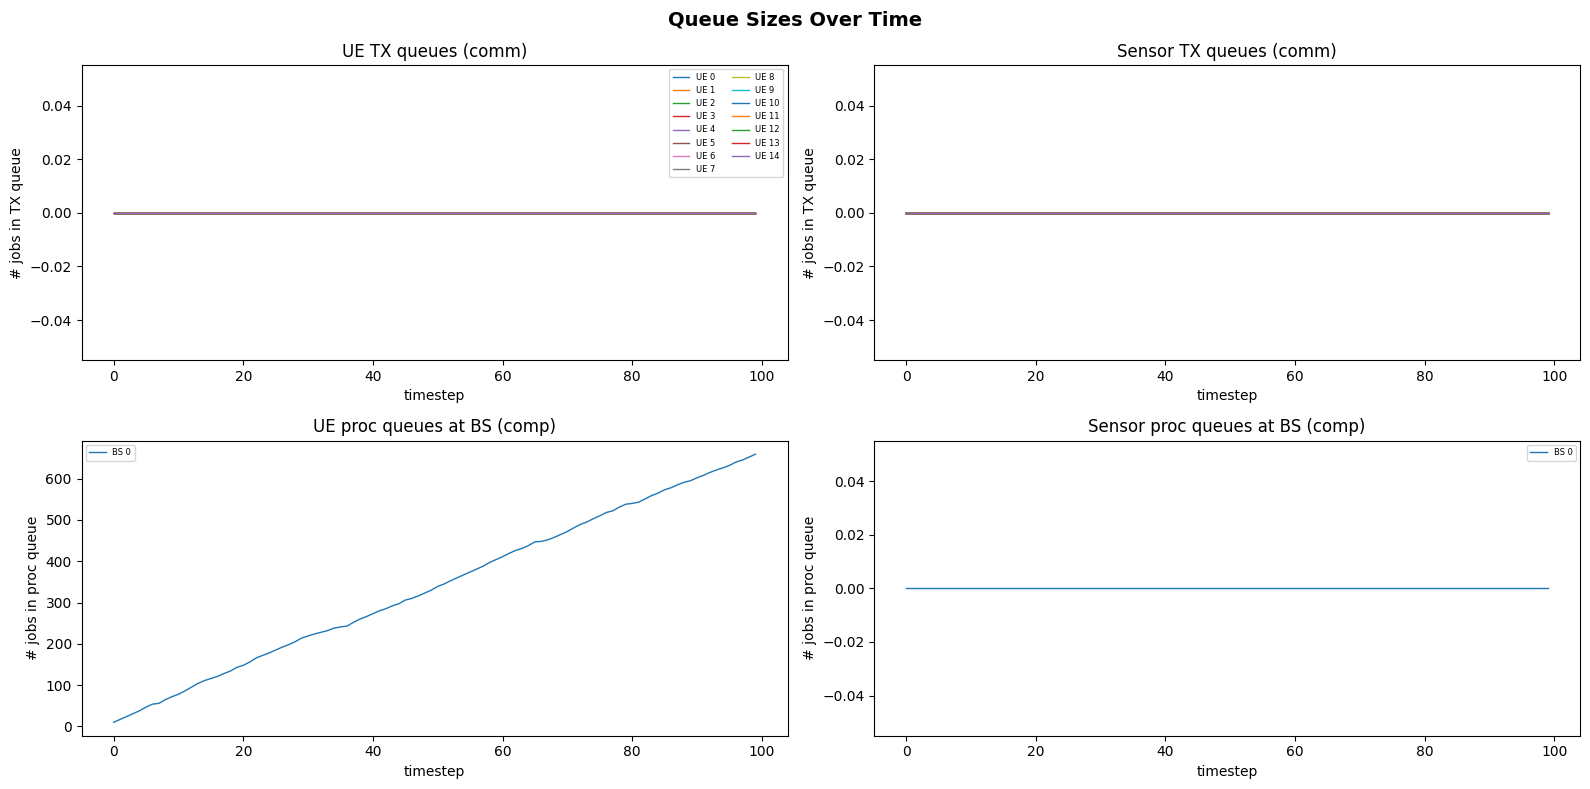

In [7]:
times = env.metrics.step_totals["time"]
tx_data = env.metrics.step_per_entity["tx_queue_jobs"]

ue_tx   = {f"UE {eid}": vals for (etype, eid), vals in sorted(tx_data.items()) if etype == "UE"}
sen_tx  = {f"Sensor {eid}": vals for (etype, eid), vals in sorted(tx_data.items()) if etype == "SENSOR"}
ue_proc = {f"BS {bid}": vals for bid, vals in env.metrics.step_per_bs["ue_proc_queue_jobs"].items()}
sn_proc = {f"BS {bid}": vals for bid, vals in env.metrics.step_per_bs["sensor_proc_queue_jobs"].items()}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("Queue Sizes Over Time", fontsize=14, fontweight="bold")

panels = [
    (axes[0, 0], ue_tx,   "UE TX queues (comm)",        "# jobs in TX queue"),
    (axes[0, 1], sen_tx,  "Sensor TX queues (comm)",     "# jobs in TX queue"),
    (axes[1, 0], ue_proc, "UE proc queues at BS (comp)", "# jobs in proc queue"),
    (axes[1, 1], sn_proc, "Sensor proc queues at BS (comp)", "# jobs in proc queue"),
]

for ax, data, title, ylabel in panels:
    for label, vals in data.items():
        ax.plot(times, vals, label=label, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("timestep")
    ax.set_ylabel(ylabel)
    if len(data) <= 20:  # only show legend when not too crowded
        ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

## 6. Detailed Metrics Tables

Raw step-by-step data for every metric. Useful for debugging or exporting to CSV.

In [8]:
# Per-entity metrics — one time series per (entity_type, entity_id)
times = env.metrics.step_totals["time"]
for metric, entity_data in env.metrics.step_per_entity.items():
    df = pd.DataFrame(
        {f"{etype} {eid}": vals for (etype, eid), vals in sorted(entity_data.items())},
        index=times
    )
    df.index.name = "time"
    print(f"\n{metric}")
    ipd.display(df)


datarate


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,SENSOR 8,SENSOR 9,...,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
time,,,,,,,,,,,,,,,,,,,,,
0,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,23.270185,22.546264,19.429404,12.326108,16.659962,15.912888,23.876617,20.613356,18.507618,13.816109
1,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,23.270185,22.546264,19.429404,12.326108,16.659962,15.912888,23.876617,20.613356,18.507618,13.816109
2,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,23.127949,22.565471,19.501013,12.358963,16.614882,15.960331,24.033875,20.703619,18.576703,13.826847
3,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,22.988299,22.582365,19.572971,12.391962,16.569874,16.007986,24.194400,20.794661,18.646276,13.837391
4,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,22.851147,22.596913,19.645273,12.425108,16.524942,16.055855,24.358322,20.886482,18.716342,13.847740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,15.535794,18.093694,22.725115,16.278253,12.957213,20.779707,23.396782,28.048694,24.384948,13.845602
96,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,15.484778,18.032751,22.663122,16.333313,12.924105,20.817161,23.251909,28.112031,24.352047,13.835213
97,23.555305,16.118029,29.517845,17.39505,20.178663,20.447003,18.116398,15.555913,21.789551,16.795377,...,15.434111,17.972108,22.599729,16.388758,12.891119,20.853489,23.109725,28.165493,24.315574,13.824628



tx_queue_jobs


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,SENSOR 8,SENSOR 9,...,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
time,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



jobs_generated


...

,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,SENSOR 8,SENSOR 9,...,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
time,,,,,,,,,,,,,,,,,,,,,
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,1,1,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,1
4,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,0,1,0,1,0,0
96,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,0,0,0,1,0
97,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,0,0,0,0,1,0



bits_transmitted


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,SENSOR 8,SENSOR 9,...,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
time,,,,,,,,,,,,,,,,,,,,,
0,399337.0,401040.0,401323.0,399830.0,400034.0,399028.0,400317.0,400559.0,399192.0,399535.0,...,499866.0,499735.0,0.0,0.0,500146.0,499240.0,0.0,0.0,499325.0,499977.0
1,401714.0,400031.0,400555.0,400307.0,399653.0,399472.0,400097.0,398959.0,401461.0,398958.0,...,501442.0,499859.0,500114.0,499753.0,499976.0,0.0,499665.0,0.0,500534.0,0.0
2,399263.0,400230.0,400943.0,399096.0,399946.0,401015.0,400215.0,399013.0,399912.0,401341.0,...,0.0,501006.0,500230.0,500880.0,0.0,499446.0,500540.0,499685.0,499981.0,499930.0
3,400323.0,399876.0,400148.0,399966.0,399572.0,399472.0,401045.0,400674.0,399655.0,400235.0,...,0.0,499750.0,500298.0,0.0,501086.0,0.0,499674.0,501008.0,0.0,499980.0
4,399660.0,398925.0,399426.0,398786.0,400079.0,400241.0,401511.0,400125.0,399462.0,400153.0,...,0.0,500935.0,0.0,499910.0,499288.0,0.0,500523.0,499697.0,500985.0,500276.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,398579.0,399758.0,399347.0,401145.0,400687.0,400536.0,398757.0,400173.0,400231.0,399355.0,...,499608.0,500013.0,0.0,499869.0,499653.0,499891.0,500102.0,0.0,0.0,499423.0
96,399626.0,400254.0,399945.0,400096.0,399701.0,399189.0,399525.0,399295.0,398850.0,399297.0,...,500472.0,499548.0,0.0,499430.0,0.0,0.0,499832.0,499963.0,500148.0,499333.0
97,399625.0,400073.0,400254.0,400519.0,400877.0,400213.0,401298.0,400963.0,400352.0,400304.0,...,500557.0,0.0,500985.0,0.0,499093.0,500374.0,0.0,500116.0,0.0,500293.0



cycles_processed


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,SENSOR 8,SENSOR 9,...,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
time,,,,,,,,,,,,,,,,,,,,,
0,24996217.0,24990269.0,24998843.0,24991169.0,25008591.0,25007396.0,25001484.0,24993541.0,24999800.0,25003757.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,25003384.0,24995023.0,24999694.0,24997279.0,24996322.0,24998441.0,24986948.0,25002572.0,25001803.0,25004831.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,24996987.0,24999089.0,24997075.0,24994755.0,24992340.0,24999087.0,25009837.0,24995142.0,25001320.0,25008882.0,...,99998419.0,99977608.0,0.0,0.0,100006250.0,100000661.0,0.0,0.0,0.0,0.0
3,25003508.0,25005725.0,25004783.0,24998606.0,25003272.0,25003741.0,24997345.0,24999164.0,24998036.0,25003707.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100003792.0,100014413.0
4,25001425.0,24997830.0,24996474.0,24997211.0,24999130.0,24996246.0,25000642.0,24996963.0,24996498.0,25003043.0,...,99999289.0,99998104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,25005561.0,25000919.0,24995841.0,24994763.0,25004124.0,25001264.0,24991821.0,25004333.0,24998393.0,24999220.0,...,0.0,0.0,100013385.0,100006284.0,0.0,100007828.0,0.0,100019086.0,0.0,0.0
96,25002288.0,24990018.0,25001819.0,25002585.0,24997160.0,24999103.0,24996520.0,25005371.0,24996580.0,25001508.0,...,99988637.0,100002746.0,0.0,0.0,0.0,0.0,0.0,0.0,100005012.0,0.0
97,25005563.0,25002312.0,24999472.0,25000603.0,24998797.0,24989833.0,25014809.0,24994453.0,24998893.0,25000824.0,...,0.0,0.0,99985829.0,99979303.0,0.0,0.0,0.0,0.0,100015244.0,0.0


## 7. Episode Summary

In [9]:
# Finalize episode — computes ep_totals and ep_per_entity
ep_summary = env.metrics.finalize(env.job_tracker)

# Episode totals
print("="*60)
print("EPISODE TOTALS")
print("="*60)
for k, v in ep_summary.items():
    if k != "per_entity":
        print(f"  {k}: {v}")

# Per-entity episode totals
print()
print("="*60)
print("EPISODE PER-ENTITY TOTALS")
print("="*60)
for field, entity_vals in ep_summary["per_entity"].items():
    df = pd.DataFrame.from_dict(entity_vals, orient='index', columns=[field])
    df.index = [f"{etype} {eid}" for (etype, eid) in df.index]
    print(f"\n  {field}")
    ipd.display(df)

# Full job lifecycle log (completed jobs only)
print()
print("="*60)
print("JOB LIFECYCLE LOG (completed jobs)")
print("="*60)
job_df = env.job_tracker.to_dataframe()
if not job_df.empty:
    ipd.display(job_df)
    env.job_tracker.save_log("logs/jobs.csv")
    print("Saved: logs/jobs.csv")


EPISODE TOTALS
  jobs_generated: 5555
  jobs_transmitted: 5555
  jobs_processed: 4896
  bits_transmitted: 2327579652.0
  cycles_processed: 152099762648.0
  job_completion_rate: 0.8813681368136813
  total_reward: 234.22123785782688
  mean_aoi: 1.0
  mean_aori: 32.275252525252526
  mean_aosi: 31.275252525252526

EPISODE PER-ENTITY TOTALS

  jobs_generated


,jobs_generated
UE 1,76
UE 2,68
UE 3,76
UE 4,69
UE 5,68
UE 6,72
UE 9,61
UE 10,70
UE 13,61
UE 14,84



  jobs_transmitted


,jobs_transmitted
UE 1,76
UE 2,68
UE 3,76
UE 4,69
UE 5,68
UE 6,72
UE 9,61
UE 10,70
UE 13,61
UE 14,84



  jobs_processed


...


  cycles_processed


,cycles_processed
UE 1,2.599998e+09
UE 2,3.000026e+09
UE 3,2.999967e+09
UE 4,2.799890e+09
UE 5,2.099992e+09
UE 6,2.999992e+09
UE 9,2.599982e+09
UE 10,2.600051e+09
UE 13,2.300018e+09
UE 14,3.099989e+09



JOB LIFECYCLE LOG (completed jobs)


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,tx_start_at,tx_end_at,proc_start_at,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,10,0,SENSOR,399337.0,24996217.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
1,11,1,SENSOR,401040.0,24990269.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
2,12,2,SENSOR,401323.0,24998843.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
3,13,3,SENSOR,399830.0,24991169.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
4,14,4,SENSOR,400034.0,25008591.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,5550,40,SENSOR,399952.0,25001281.0,99,99,99,99,99,0,0,0,0,NaN,NaN,NaN,0,NaN
4892,5551,41,SENSOR,399130.0,24997138.0,99,99,99,99,99,0,0,0,0,NaN,NaN,NaN,0,NaN
4893,5552,42,SENSOR,399801.0,25005456.0,99,99,99,99,99,0,0,0,0,NaN,NaN,NaN,0,NaN
4894,5553,43,SENSOR,399537.0,24997078.0,99,99,99,99,99,0,0,0,0,NaN,NaN,NaN,0,NaN


Saved: logs/jobs.csv


## 8. Sensor Synchronisation & Age of Information

UE jobs are only processed once a fresh sensor snapshot is available from the nearest sensor.  
Three metrics capture how fresh that data is:

| Metric | Formula | Interpretation |
|---|---|---|
| **AoRI** | `proc_end_at − generated_at` | UE job's end-to-end latency |
| **AoSI** | `sensor_snapshot_at − generated_at` | How old the sensor data was when the UE job was born |
| **AoI** | `proc_end_at − sensor_snapshot_at` | Staleness of sensor data at processing time |

In [10]:
job_df = env.job_tracker.to_dataframe()
ue_df = job_df[job_df['entity_type'] == 'UE'].copy()

# --- AoI / AoRI / AoSI stats ---
print("="*60)
print("AGE METRICS (UE jobs)")
print("="*60)
for col, label in [('aori', 'AoRI'), ('aosi', 'AoSI'), ('aoi', 'AoI')]:
    s = ue_df[col].dropna()
    print(f"  {label:5s}  mean={s.mean():.2f}  max={s.max():.0f}  min={s.min():.0f}")

# --- Per-UE breakdown ---
print()
print("="*60)
print("PER-UE AGE METRICS")
print("="*60)
per_ue = ue_df.groupby('entity_id')[['aori', 'aosi', 'aoi']].mean().round(2)
per_ue.index = [f'UE {i}' for i in per_ue.index]
ipd.display(per_ue)

# --- Full UE job table with sensor context columns ---
print()
print("UE JOB LOG")
cols = ['job_id', 'entity_id', 'generated_at', 'proc_end_at',
        'nearest_sensor_id', 'sensor_snapshot_at', 'aori', 'aosi', 'aoi']
ipd.display(ue_df[cols].reset_index(drop=True))

AGE METRICS (UE jobs)
  AoRI   mean=32.28  max=62  min=1
  AoSI   mean=31.28  max=61  min=0
  AoI    mean=1.00  max=1  min=1

PER-UE AGE METRICS


,aori,aosi,aoi
UE 0,33.26,32.26,1.0
UE 1,27.27,26.27,1.0
UE 2,31.90,30.90,1.0
UE 3,30.00,29.00,1.0
UE 4,28.57,27.57,1.0
UE 5,33.14,32.14,1.0
UE 6,31.73,30.73,1.0
UE 7,36.20,35.20,1.0
UE 8,36.19,35.19,1.0
UE 9,31.85,30.85,1.0



UE JOB LOG


,job_id,entity_id,generated_at,proc_end_at,nearest_sensor_id,sensor_snapshot_at,aori,aosi,aoi
0,0,1,0,1,40.0,0.0,1,0.0,1.0
1,1,2,0,1,7.0,0.0,1,0.0,1.0
2,2,3,0,1,27.0,0.0,1,0.0,1.0
3,3,4,0,1,14.0,0.0,1,0.0,1.0
4,4,5,0,2,2.0,1.0,2,1.0,1.0
...,...,...,...,...,...,...,...,...,...
391,2056,5,37,98,40.0,97.0,61,60.0,1.0
392,2057,6,37,99,2.0,98.0,62,61.0,1.0
393,2058,7,37,99,19.0,98.0,62,61.0,1.0
394,2059,8,37,99,37.0,98.0,62,61.0,1.0
